## Conditioning on a trial having home content, does it occur with future correct?

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [4]:
from spyglass.shijiegu.changeOfMind import nodes, color_by_rat
from spyglass.shijiegu.decodeHelpers import session2position_name

[2026-04-02 09:08:49,066][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[09:09:01][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:09:01][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:09:01][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:09:01][WARNING] Spyglass: Deprecation: this class has b

In [70]:
def return_save_name(animal, parameter_name, d1, d2, minimum_duration, min_posterior, proportion = 0.1, use_1d = 1):
    save_name = f'{animal.lower()}_{parameter_name}_{d1}_{d2}_t{minimum_duration}_minp{min_posterior}_p{proportion}_use1d{use_1d}_remoteGLM'
    return save_name

def sd_err_p(p, N):
    return np.sqrt(p * (1-p) / N)

In [5]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

# encoding_set = 'all_maze'
# classifier_param_name = 'default_decoding_gpu_4armMaze'

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']#'20231111']

In [6]:
proportion = 0.1
use_1d = 1
#parameter_name = "params_both_max_all_maze_2_state" 
parameter_name = "params_both_max_run_time_2_state"#"params_both_max_run_time_2_state" #"params_both_max_run_time_2_state"
minimum_duration = 0.02
min_posterior = 0.2

eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
response_h, 8
response_nh, 25
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
response_h, 6
response_nh, 15
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
response_h, 4
response_nh, 85
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
response_h, 18
response_nh, 90


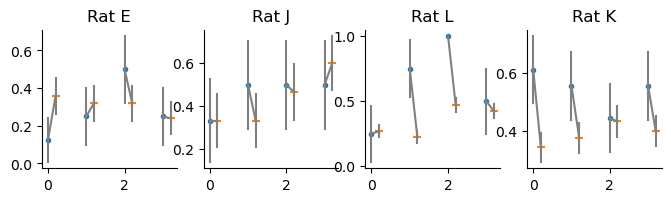

In [84]:
animals = ["eliot","julio","klein","lewis"]#["lewis","molly","julio","klein"]

fig, axes = plt.subplots(1,len(animals), figsize=(8, 1.8))

dt = 0.38
dx= 0.05

ax = axes
animal_ind = 0
for animal in ["eliot", "julio","lewis","klein"]:#animals:
    p_h = [] #"previous", "previously_rewarded", "future", "future_correct"
    p_nh = []
    n_h= []
    n_nh = []

    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                     minimum_duration = minimum_duration, min_posterior= min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all = data["features_all"]
    # features are: "previous", "previously_rewarded", "future", "future_correct"
    response_all = data["response_all"]
    home_replay = np.array(data["home_replay_all"]) > 0

    # with home rep.
    features_h = [features_all[ind] for ind in range(len(home_replay)) if home_replay[ind]]
    response_h = [np.array(response_all[ind]).reshape((-1,1)) for ind in range(len(home_replay)) if home_replay[ind]]
    # without home rep.
    features_nh = [features_all[ind] for ind in range(len(home_replay)) if not home_replay[ind]]
    response_nh = [np.array(response_all[ind]).reshape((-1,1)) for ind in range(len(home_replay)) if not home_replay[ind]]

    print("response_h,", len(response_h))
    print("response_nh,", len(response_nh))

    features_h = np.vstack(features_h)
    response_h = np.vstack(response_h)
    features_nh = np.vstack(features_nh)
    response_nh = np.vstack(response_nh)
    
    for c in range(4):
        
        data_c = response_h[features_h[:,c] > 0].astype("int")
        p_h.append(np.mean(data_c))
        n_h.append(len(data_c))

        data_c = response_nh[features_nh[:,c] > 0].astype("int")
        p_nh.append(np.mean(data_c))
        n_nh.append(len(data_c))

    # get std err
    sd_h = sd_err_p(np.array(p_h), np.array(n_h))
    sd_nh = sd_err_p(np.array(p_nh), np.array(n_nh))

    
    axes[animal_ind].scatter([0,1,2,3], p_h, color = "C0", marker = ".")
    axes[animal_ind].scatter(np.array([0,1,2,3]) + 0.2, p_nh, color = "C1", marker = "+")
    for c in [0,1,2,3]:
        axes[animal_ind].plot([c, c + 0.2], [p_h[c], p_nh[c]], color = "grey")
        
        axes[animal_ind].plot([c, c], [p_h[c] - sd_h[c], p_h[c] + sd_h[c]], color = "grey")
        axes[animal_ind].plot([c + 0.2, c + 0.2], [p_nh[c] - sd_nh[c], p_nh[c] + sd_nh[c]],
                              color = "grey")

    axes[animal_ind].set_title(f"Rat {animal[0].upper()}")
    axes[animal_ind].spines['top'].set_visible(False)
    axes[animal_ind].spines['right'].set_visible(False)
    
    animal_ind += 1
    

### Does home trials associate with more remote rep. in general?

eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
response_h, 8
response_nh, 25
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
response_h, 6
response_nh, 15
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
response_h, 4
response_nh, 85
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
response_h, 18
response_nh, 90


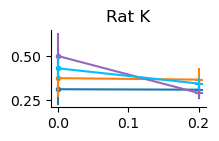

In [96]:
animals = ["eliot","julio","klein","lewis"]#["lewis","molly","julio","klein"]

fig, axes = plt.subplots(1,1, figsize=(2, 1), sharey = True)

dt = 0.38
dx= 0.05

ax = axes
animal_ind = 0
for animal in ["eliot", "julio","lewis","klein"]:#animals:
    p_h = [] #"previous", "previously_rewarded", "future", "future_correct"
    p_nh = []
    n_h= []
    n_nh = []

    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                     minimum_duration = minimum_duration, min_posterior= min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all = data["features_all"]
    # features are: "previous", "previously_rewarded", "future", "future_correct"
    response_all = data["response_all"]
    home_replay = np.array(data["home_replay_all"]) > 0

    # with home rep.
    response_h = [np.array(response_all[ind]).reshape((-1,1)) for ind in range(len(home_replay)) if home_replay[ind]]
    # without home rep.
    response_nh = [np.array(response_all[ind]).reshape((-1,1)) for ind in range(len(home_replay)) if not home_replay[ind]]

    print("response_h,", len(response_h))
    print("response_nh,", len(response_nh))

    response_h = np.vstack(response_h)
    response_nh = np.vstack(response_nh)
    
    p_h = np.mean(response_h)
    p_nh = np.mean(response_nh)

    # get std err
    sd_h = sd_err_p(np.array(p_h), len(response_h))
    sd_nh = sd_err_p(np.array(p_nh), len(response_nh))

    
    ax.scatter(0, p_h, color = color_by_rat[animal], marker = ".")
    ax.scatter(0.2, p_nh, color = color_by_rat[animal], marker = "+")
    ax.plot([0, 0.2], [p_h, p_nh], color = color_by_rat[animal],)
        
    ax.plot([0, 0], [p_h - sd_h, p_h + sd_h], color = color_by_rat[animal],)
    ax.plot([0 + 0.2, 0 + 0.2], [p_nh - sd_nh, p_nh + sd_nh],
                              color = color_by_rat[animal],)

    ax.set_title(f"Rat {animal[0].upper()}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    animal_ind += 1
    

In [61]:
np.mean(response_h.astype("int"))

0.25

In [53]:
p_h

[0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.5]

In [51]:
p_nh

[0.0, 0.0, 1.0, 0.0]

In [25]:
response_h.shape

(1, 4)